# Unsupervised ML Models

### 1. K-means Clustering

In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("Day 11 data\\mall.csv")

In [6]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
df = df.drop(columns = ["CustomerID","Genre"])

In [8]:
x = df.iloc[:,[0,1]].values

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

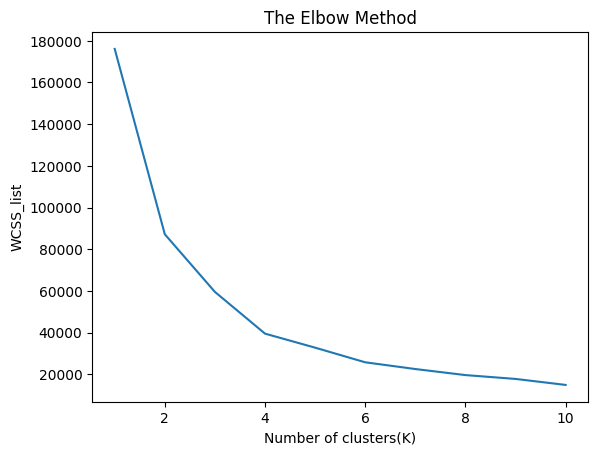

In [11]:
a =[]

for i in range(1,11):
    b = KMeans(n_clusters=i,init="k-means++",random_state=42)
    b.fit(x)
    a.append(b.inertia_)
plt.plot(range(1,11),a)
plt.title("The Elbow Method")
plt.xlabel("Number of clusters(K)")
plt.ylabel("WCSS_list")
plt.show()
    

In [12]:
b = KMeans(n_clusters=4,init="k-means++",random_state=42)
y_predict = b.fit_predict(x)

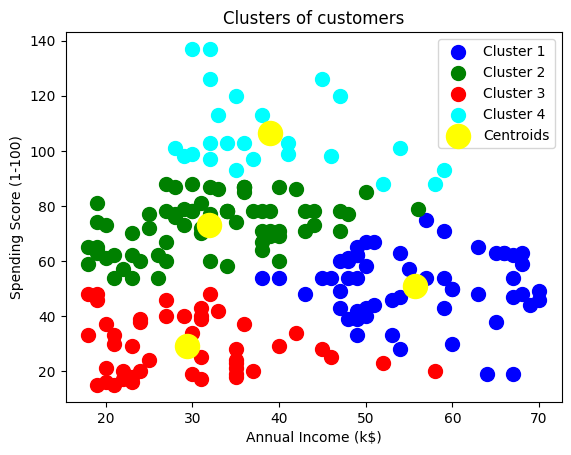

In [13]:
plt.scatter(x[y_predict == 0,0],x[y_predict == 0,1],s=100,c="blue",label="Cluster 1")
plt.scatter(x[y_predict == 1,0],x[y_predict == 1,1],s=100,c="green",label="Cluster 2")
plt.scatter(x[y_predict == 2,0],x[y_predict == 2,1],s=100,c="red",label="Cluster 3")
plt.scatter(x[y_predict == 3,0],x[y_predict == 3,1],s=100,c="cyan",label="Cluster 4")

plt.scatter(b.cluster_centers_[:,0],b.cluster_centers_[:,1],s=300,c="yellow",label="Centroids")

plt.title("Clusters of customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

### 2. PCA : PRINCIPLE COMPONENT ANALYSIS

In [14]:
df2 = pd.read_csv("ML_Model_API_Testing\\Social_Network_Ads.csv")

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [16]:
df2.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [17]:
df2 = df2.drop(columns = ["User ID","Gender"])

In [18]:
df2.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [20]:
x = df2.drop(columns = ["Purchased"], axis=1)
y= df2["Purchased"]

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
pipe = Pipeline([
    ("scaler",StandardScaler()),
    ("pca",PCA(n_components=2)),
    ("classifier",RandomForestClassifier(n_estimators=100,random_state=42))
])

In [23]:
pipe

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'


In [24]:
pipe.fit(x_train,y_train)

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'


In [25]:
y_pred = pipe.predict(x_test)

In [26]:
accuracy_score(y_test,y_pred)

0.8875

### 3. Apriori

In [29]:
df3 = pd.read_csv("Day 11 data\\market_basket.csv",header=None)

In [30]:
df3.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
df3.shape

(7501, 20)

In [34]:
#Data Processing

transactions = []
for i in range(0,7501):
    transactions.append([str(df3.values[i,j]) for j in range(0,20)])

#Training the dataset
from apyori import apriori
rules = apriori(transactions,
                min_support = 0.003, #(3 items* 7 days in week )/(total rowsin dataset -> 7501)
                min_confidence = 0.2,
                min_lift = 3,
                min_length = 2
                )

#visualizing the results

a=list(rules)
result = [list(a[i][0] for i in range(0,len(a)))]

In [36]:
result

[[frozenset({'chicken', 'light cream'}),
  frozenset({'escalope', 'mushroom cream sauce'}),
  frozenset({'escalope', 'pasta'}),
  frozenset({'fromage blanc', 'honey'}),
  frozenset({'ground beef', 'herb & pepper'}),
  frozenset({'ground beef', 'tomato sauce'}),
  frozenset({'light cream', 'olive oil'}),
  frozenset({'olive oil', 'whole wheat pasta'}),
  frozenset({'pasta', 'shrimp'}),
  frozenset({'avocado', 'milk', 'spaghetti'}),
  frozenset({'burgers', 'cake', 'milk'}),
  frozenset({'burgers', 'chocolate', 'turkey'}),
  frozenset({'burgers', 'milk', 'turkey'}),
  frozenset({'cake', 'frozen vegetables', 'tomatoes'}),
  frozenset({'cereals', 'ground beef', 'spaghetti'}),
  frozenset({'chicken', 'ground beef', 'milk'}),
  frozenset({'chicken', 'light cream', 'nan'}),
  frozenset({'chicken', 'milk', 'olive oil'}),
  frozenset({'chicken', 'olive oil', 'spaghetti'}),
  frozenset({'chocolate', 'frozen vegetables', 'shrimp'}),
  frozenset({'chocolate', 'ground beef', 'herb & pepper'}),
  fro